# Using GDELT library in Python we retreive the latest global event data
- this turned out to be very useful for our project as it is very easy to retrieve and process the data
- it returns data in a structured format which can be easily analyzed
- since it's very large dataset we will only grab previous week for our analysis

In [1]:
import gdelt
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt

gd2 = gdelt.gdelt(version=2)

gkg = gd2.Search(["2025 Dec 13","2025 Dec 19"], table="gkg", coverage=True, output="pandas")
print(gkg.shape)
print(gkg.columns)
gkg.head()

here
(789860, 27)
Index(['GKGRECORDID', 'DATE', 'SourceCollectionIdentifier', 'SourceCommonName',
       'DocumentIdentifier', 'Counts', 'V2Counts', 'Themes', 'V2Themes',
       'Locations', 'V2Locations', 'Persons', 'V2Persons', 'Organizations',
       'V2Organizations', 'V2Tone', 'Dates', 'GCAM', 'SharingImage',
       'RelatedImages', 'SocialImageEmbeds', 'SocialVideoEmbeds', 'Quotations',
       'AllNames', 'Amounts', 'TranslationInfo', 'Extras'],
      dtype='object')


,GKGRECORDID,DATE,SourceCollectionIdentifier,SourceCommonName,DocumentIdentifier,Counts,V2Counts,Themes,V2Themes,Locations,...,GCAM,SharingImage,RelatedImages,SocialImageEmbeds,SocialVideoEmbeds,Quotations,AllNames,Amounts,TranslationInfo,Extras
0,20251213000000-0,20251213000000,1,calcuttanews.net,http://www.calcuttanews.net/news/278752092/mag...,NaN,NaN,TAX_FNCACT;TAX_FNCACT_FOOTBALLER;TAX_FNCACT_MA...,"TAX_FNCACT_MAGICIAN,1134;TAX_FNCACT_FOOTBALLER...","4#Hyderabad, Andhra Pradesh, India#IN#IN02#17....",...,"wc:303,c12.1:29,c12.10:17,c12.12:3,c12.13:5,c1...",https://image.chitra.live/api/v1/wps/e112af4/5...,NaN,NaN,NaN,NaN,"West Bengal,23;Lionel Messi,124;Salt Lake Stad...",NaN,NaN,<PAGE_TITLE>Magic in the air as Lionel Messi r...
1,20251213000000-1,20251213000000,1,dailypolitical.com,https://www.dailypolitical.com/2025/12/12/falc...,NaN,NaN,ENV_METALS;WB_2936_GOLD;WB_507_ENERGY_AND_EXTR...,"TAX_FNCACT_ANALYST,1047;ENV_METALS,21;ENV_META...",1#Canada#CA#CA#60#-96#CA,...,"wc:190,c12.1:8,c12.10:17,c12.12:3,c12.13:1,c12...",NaN,NaN,NaN,NaN,NaN,"Falcon Gold,22;Get Free Report,63;Get Free Rep...","796,shares changed hands during,150;360,shares...",NaN,<PAGE_LINKS>https://www.dailypolitical.com/dai...
2,20251213000000-2,20251213000000,1,wvik.org,https://www.wvik.org/illinois/2025-12-12/appea...,ARREST#200#immigrants#1#United States#US#US#39...,ARREST#200#immigrants#1#United States#US#US#39...,GOV_WARRANTLESS;IMMIGRATION;WB_2670_JOBS;WB_27...,"DEMOCRACY,5164;TAX_FNCACT_IMMIGRANT,1555;TAX_F...",1#United States#US#US#39.828175#-98.5795#US,...,"wc:862,c1.3:1,c12.1:99,c12.10:70,c12.12:21,c12...",http://npr-brightspot.s3.amazonaws.com/97/de/5...,NaN,NaN,NaN,1996|50||whom both parties agree were arrested...,"Circuit Court,287;Judge Jeffrey Cummings,973;H...","100,of immigrants slated for,132;2,orders,754;...",NaN,<PAGE_LINKS>https://capitolnewsillinois.com/ne...
3,20251213000000-3,20251213000000,1,theepochtimes.com,https://www.theepochtimes.com/article/how-the-...,NaN,NaN,HEALTH_VACCINATION;WB_642_CHILD_HEALTH;WB_1459...,"TAX_FNCACT_OFFICIALS,202;GENERAL_HEALTH,192;ME...",NaN,...,"wc:39,c12.1:4,c12.10:2,c12.13:2,c12.5:4,c12.8:...",https://img.theepochtimes.com/assets/uploads/2...,NaN,NaN,NaN,NaN,"President Donald Trump,101",NaN,NaN,<PAGE_LINKS>https://www.theepochtimes.com/arti...
4,20251213000000-4,20251213000000,1,theage.com.au,https://www.theage.com.au/world/north-america/...,NaN,NaN,EPU_POLICY;EPU_POLICY_WHITE_HOUSE;TAX_FNCACT;T...,"LEGISLATION,272;TAX_FNCACT_AIDES,2435;TAX_POLI...","3#Washington, Washington, United States#US#USD...",...,"wc:376,c1.1:1,c1.3:1,c1.4:1,c12.1:25,c12.10:41...",https://static.ffx.io/images/$zoom_0.1847%2C$m...,https://static.ffx.io/images/$zoom_0.378%2C$mu...,NaN,NaN,192|146||President Trump has full legal author...,"White House,12;Davis Ingle,34;White House,148;...","3,months after construction began,1656;",NaN,<PAGE_AUTHORS>Bill Barrow</PAGE_AUTHORS><PAGE_...


# Extract Tone from GDELT Data and create new columns with Tone Categories

In [2]:
def parse_tone_bundle(v, k=7):
    """Parse comma-separated tone bundle into floats; pad/NaN on errors."""
    if not isinstance(v, str) or v.strip() == "":
        return [np.nan]*k
    parts = v.split(",")
    parts += [None]*(k - len(parts))
    out = []
    for p in parts[:k]:
        try:
            out.append(float(p))
        except:
            out.append(np.nan)
    return out

tone_col = "V2Tone" if "V2Tone" in gkg.columns else ("Tone" if "Tone" in gkg.columns else None)
if tone_col is None:
    raise KeyError("No V2Tone or Tone column found. Print gkg.columns to inspect.")

tone_cols = ["tone","pos","neg","polarity","activity_ref","self_group_ref","wordcount"]
gkg[tone_cols] = gkg[tone_col].apply(lambda x: pd.Series(parse_tone_bundle(x, k=len(tone_cols))))


# Extract date from datetime column with proper formatting and extract year, month, day

In [3]:
def ensure_datetime(df):
    if "date_dt" in df.columns:
        return df
    if "DATE" in df.columns:
        df = df.copy()
        df["date_dt"] = pd.to_datetime(df["DATE"], format="%Y%m%d%H%M%S", errors="coerce")
        df = df.dropna(subset=["date_dt"])
        return df
    raise KeyError("Need DATE or date_dt to do time-based EDA.")

def count_list(s, sep=";"):
    if not isinstance(s, str) or s.strip() == "":
        return 0
    return len([x for x in s.split(sep) if x.strip()])

def explode_list_col(df, col, sep=";"):
    """Explode a semicolon-separated list column into long form."""
    if col not in df.columns:
        raise KeyError(f"Missing column: {col}")
    out = df[[c for c in df.columns if c != col]].copy()
    tmp = df[col].fillna("").astype(str).str.split(sep)
    out[col] = tmp
    out = out.explode(col)
    out[col] = out[col].astype(str).str.strip()
    out = out[out[col] != ""]
    return out

gkg = ensure_datetime(gkg)
gkg["day"] = gkg["date_dt"].dt.floor("D")
gkg["hour"] = gkg["date_dt"].dt.hour
gkg["dow"] = gkg["date_dt"].dt.day_name()


# Check percentage of missing values in each column
- we can clearly observe that some columns have a very high percentage of missing values, but those are least relevant columns for our analysis
- the most important columns have very low percentage of missing values which is good for our analysis

In [4]:
miss = (gkg.isna().mean().sort_values(ascending=False) * 100).round(5)
print(miss.head(30))


TranslationInfo               100.00000
SocialImageEmbeds              88.51695
RelatedImages                  87.58565
V2Counts                       85.70899
Counts                         85.70899
Quotations                     78.40807
Dates                          64.52042
SocialVideoEmbeds              48.53265
V2Organizations                28.44238
Organizations                  25.53845
Amounts                        25.33765
V2Locations                    24.85858
Locations                      24.73603
V2Persons                      23.27830
Persons                        22.40068
SharingImage                   13.01370
V2Themes                       10.74735
Themes                         10.74659
AllNames                        4.78984
GKGRECORDID                     0.00000
SourceCollectionIdentifier      0.00000
DATE                            0.00000
DocumentIdentifier              0.00000
SourceCommonName                0.00000
V2Tone                          0.00000


# Visualise the missing values using a heatmap
- this heatmap gives a clear visual representation of the missing values in the dataset

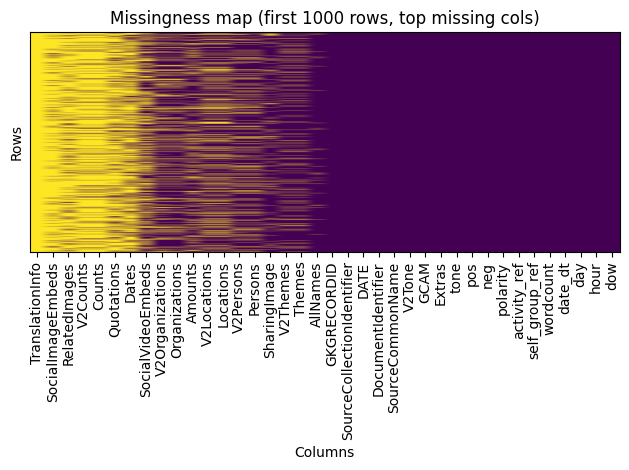

In [ ]:
cols = miss.index[:40].tolist()
mat = gkg[cols].isna().astype(int).head(1000).to_numpy()

plt.figure()
plt.imshow(mat, aspect="auto")
plt.title("Missingness map (first 1000 rows, top missing cols)")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.xticks(range(len(cols)), cols, rotation=90)
plt.yticks([])
plt.tight_layout()
plt.show()


# Check for duplicate rows in the dataset

In [6]:
for key in ["GKGRECORDID", "GKGRecordID", "DocumentIdentifier"]:
    if key in gkg.columns:
        dup_rate = gkg.duplicated(subset=[key]).mean()
        print(f"Duplicate rate by {key}: {dup_rate:.3%}")


Duplicate rate by GKGRECORDID: 0.000%
Duplicate rate by DocumentIdentifier: 0.000%


# Creating a heatmap to visualise document volumes over time (by day and hour of day)
- We can clearly see the patterns of document volumes over time
- there are certain hours of the day where document volumes are significantly higher (between 4pm to midnight) in UTC time
- there is also a weekly pattern where weekdays have higher document volumes compared to weekends (sunday morning has the lowest volume of documents)

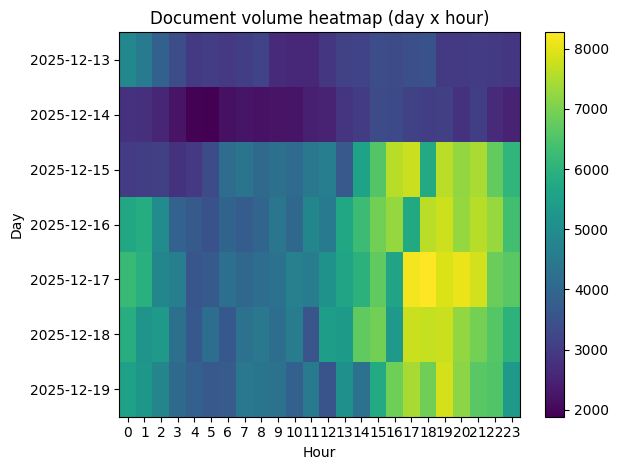

In [7]:
vol = (gkg.groupby(["day","hour"]).size().unstack(fill_value=0)).sort_index()

plt.figure()
plt.imshow(vol.to_numpy(), aspect="auto")
plt.title("Document volume heatmap (day x hour)")
plt.xlabel("Hour")
plt.ylabel("Day")
plt.xticks(range(vol.shape[1]), vol.columns)
plt.yticks(range(vol.shape[0]), [d.strftime("%Y-%m-%d") for d in vol.index])
plt.colorbar()
plt.tight_layout()
plt.show()


# Here we create a heatmap to visualise the average tone over time
- Since the data includes the information about Bondi Beach attack (14th Dec 2025), we can clearly see a significant dip in average tone on that day

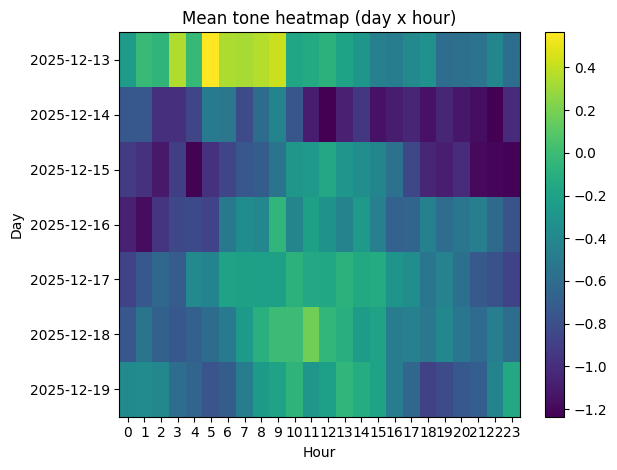

In [8]:
if "tone" in gkg.columns:
    mt = (gkg.groupby(["day","hour"])["tone"].mean().unstack())
    plt.figure()
    plt.imshow(mt.to_numpy(), aspect="auto")
    plt.title("Mean tone heatmap (day x hour)")
    plt.xlabel("Hour")
    plt.ylabel("Day")
    plt.xticks(range(mt.shape[1]), mt.columns)
    plt.yticks(range(mt.shape[0]), [d.strftime("%Y-%m-%d") for d in mt.index])
    plt.colorbar()
    plt.tight_layout()
    plt.show()


# Here let's create a tone distribution plot for the entire dataset and also boxplots for tone per day

tone p01/p99: -11.6838487972509 9.623109945535983


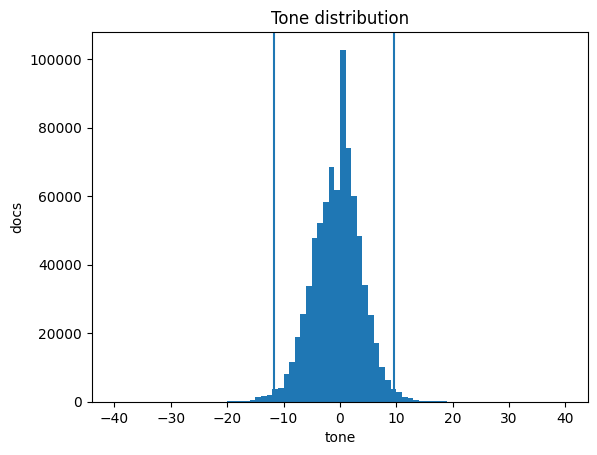

In [9]:
if "tone" in gkg.columns:
    x = gkg["tone"].dropna().astype(float)
    p1, p99 = x.quantile([0.01, 0.99])
    print("tone p01/p99:", float(p1), float(p99))

    plt.figure()
    plt.hist(x, bins=80)
    plt.title("Tone distribution")
    plt.xlabel("tone")
    plt.ylabel("docs")
    plt.axvline(p1)
    plt.axvline(p99)
    plt.show()


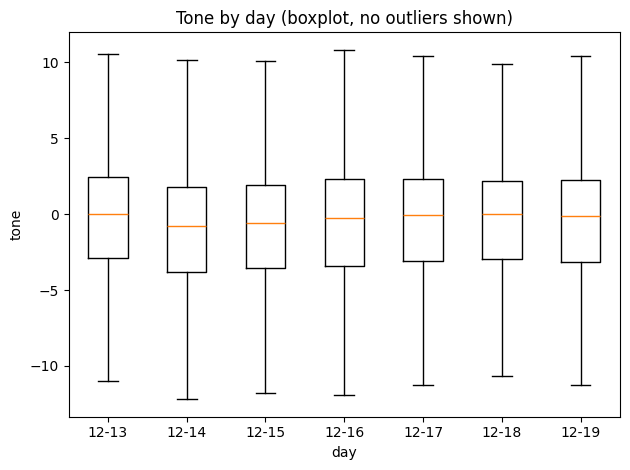

In [10]:
if "tone" in gkg.columns:
    daily = gkg.dropna(subset=["tone"]).copy()
    days = sorted(daily["day"].unique())
    data = [daily.loc[daily["day"]==d, "tone"].astype(float).values for d in days]

    plt.figure()
    plt.boxplot(data, tick_labels=[pd.Timestamp(d).strftime("%m-%d") for d in days], showfliers=False)
    plt.title("Tone by day (boxplot, no outliers shown)")
    plt.xlabel("day")
    plt.ylabel("tone")
    plt.tight_layout()
    plt.show()


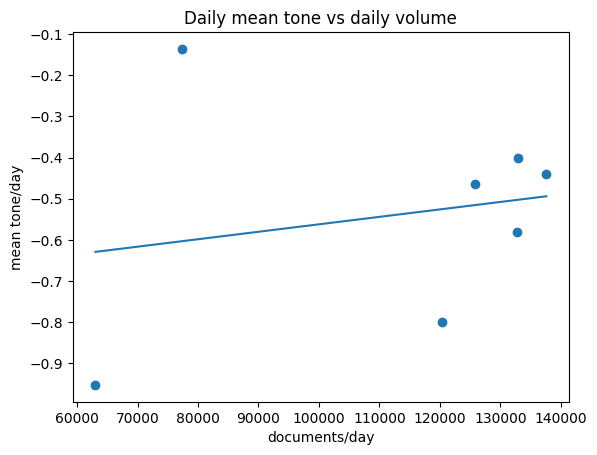

In [11]:
if "tone" in gkg.columns:
    daily = (gkg.groupby("day")
             .agg(documents=("day","size"), mean_tone=("tone","mean"))
             .reset_index())
    x = daily["documents"].to_numpy()
    y = daily["mean_tone"].to_numpy()

    plt.figure()
    plt.scatter(x, y)
    if len(x) >= 2:
        m, b = np.polyfit(x, y, 1)
        xx = np.linspace(x.min(), x.max(), 100)
        plt.plot(xx, m*xx + b)
    plt.title("Daily mean tone vs daily volume")
    plt.xlabel("documents/day")
    plt.ylabel("mean tone/day")
    plt.show()


In [12]:
if "tone" in gkg.columns:
    daily = (gkg.groupby("day")
             .agg(documents=("day","size"), mean_tone=("tone","mean"))
             .sort_index())
    max_lag = 3
    for lag in range(-max_lag, max_lag+1):
        corr = daily["documents"].corr(daily["mean_tone"].shift(lag))
        print(f"corr(documents, mean_tone shifted {lag:+d}d): {corr:.3f}")


corr(documents, mean_tone shifted -3d): 0.378
corr(documents, mean_tone shifted -2d): 0.764
corr(documents, mean_tone shifted -1d): 0.930
corr(documents, mean_tone shifted +0d): 0.201
corr(documents, mean_tone shifted +1d): -0.613
corr(documents, mean_tone shifted +2d): -0.876
corr(documents, mean_tone shifted +3d): -0.367


# Create a tone daily mean time series plot with rolling average

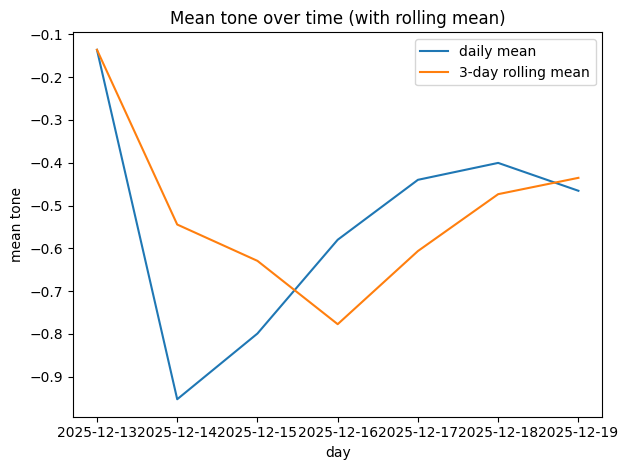

In [13]:
if "tone" in gkg.columns:
    daily = (gkg.groupby("day")["tone"].mean().sort_index())
    roll = daily.rolling(3, min_periods=1)
    plt.figure()
    plt.plot(daily.index, daily.values, label="daily mean")
    plt.plot(roll.mean().index, roll.mean().values, label="3-day rolling mean")
    plt.title("Mean tone over time (with rolling mean)")
    plt.xlabel("day")
    plt.ylabel("mean tone")
    plt.legend()
    plt.tight_layout()
    plt.show()


# Now let's create a top sources distribution (news sources) plot
- we can see the top sources of our data and there is a clrear winner in terms of number of articles published

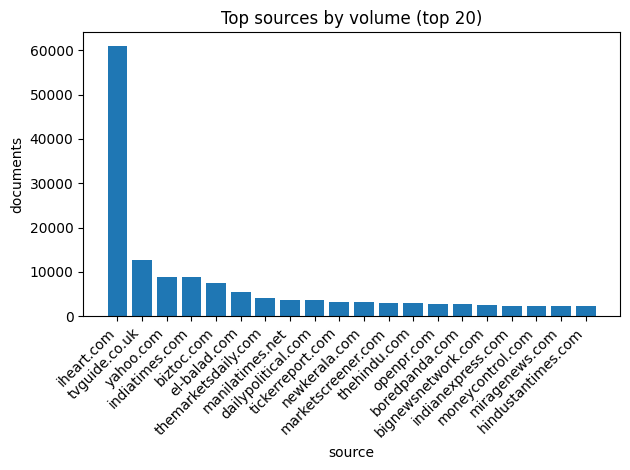

In [14]:
import matplotlib.pyplot as plt

src_col = next((c for c in ["SourceCommonName", "sourceCommonName", "Source"] if c in gkg.columns), None)

if src_col and "tone" in gkg.columns:
    top = (gkg.groupby(src_col)
           .agg(documents=("tone","size"), mean_tone=("tone","mean"))
           .sort_values("documents", ascending=False)
           .head(20))

    labels = top.index.astype(str).tolist()
    values = top["documents"].to_numpy()

    plt.figure()
    plt.bar(range(len(top)), values)
    plt.title("Top sources by volume (top 20)")
    plt.xlabel("source")
    plt.ylabel("documents")

    plt.xticks(range(len(top)), labels, rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


# Here we can analyse the top theme for the dataset with average tone of it 

                                         mentions  mean_tone
Themes                                                      
TAX_FNCACT                                 608576  -0.880842
EPU_POLICY                                 290375  -1.681920
CRISISLEX_CRISISLEXREC                     272404  -2.977761
TAX_ETHNICITY                              246991  -0.945422
UNGP_FORESTS_RIVERS_OCEANS                 226089  -0.352853
WB_696_PUBLIC_SECTOR_MANAGEMENT            215940  -2.151963
CRISISLEX_C07_SAFETY                       194332  -3.505467
USPEC_POLITICS_GENERAL1                    194168  -1.386175
SOC_POINTSOFINTEREST                       186942  -2.095861
LEADER                                     184467  -1.462625
TAX_WORLDLANGUAGES                         164491  -0.864139
WB_621_HEALTH_NUTRITION_AND_POPULATION     163053  -1.936624
EPU_ECONOMY_HISTORIC                       156853   0.349342
GENERAL_HEALTH                             155790  -1.761823
USPEC_POLICY1           

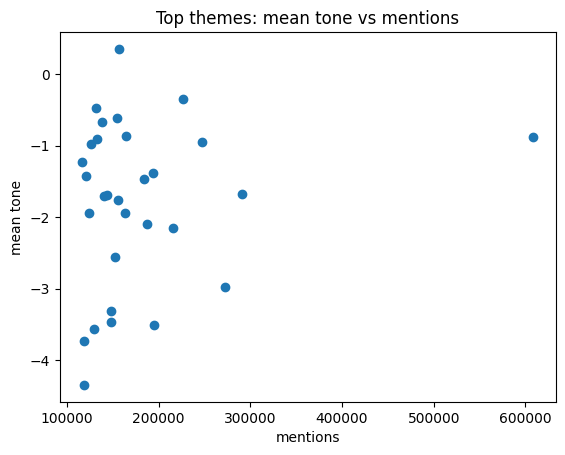

In [15]:
theme_col = "Themes" if "Themes" in gkg.columns else ("V2Themes" if "V2Themes" in gkg.columns else None)

if theme_col and "tone" in gkg.columns:
    long = explode_list_col(gkg[[theme_col, "tone"]].dropna(subset=["tone"]), theme_col)
    theme_stats = (long.groupby(theme_col)
                   .agg(mentions=(theme_col,"size"), mean_tone=("tone","mean"))
                   .sort_values("mentions", ascending=False)
                   .head(30))
    print(theme_stats.head(20))

    plt.figure()
    plt.scatter(theme_stats["mentions"], theme_stats["mean_tone"])
    plt.title("Top themes: mean tone vs mentions")
    plt.xlabel("mentions")
    plt.ylabel("mean tone")
    plt.show()


# here we can visualise with heatmap the co-occurrence of top themes in the dataset (two themes appearing together in the same article)

C:\Users\hucu\AppData\Local\Temp\ipykernel_37112\531718795.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


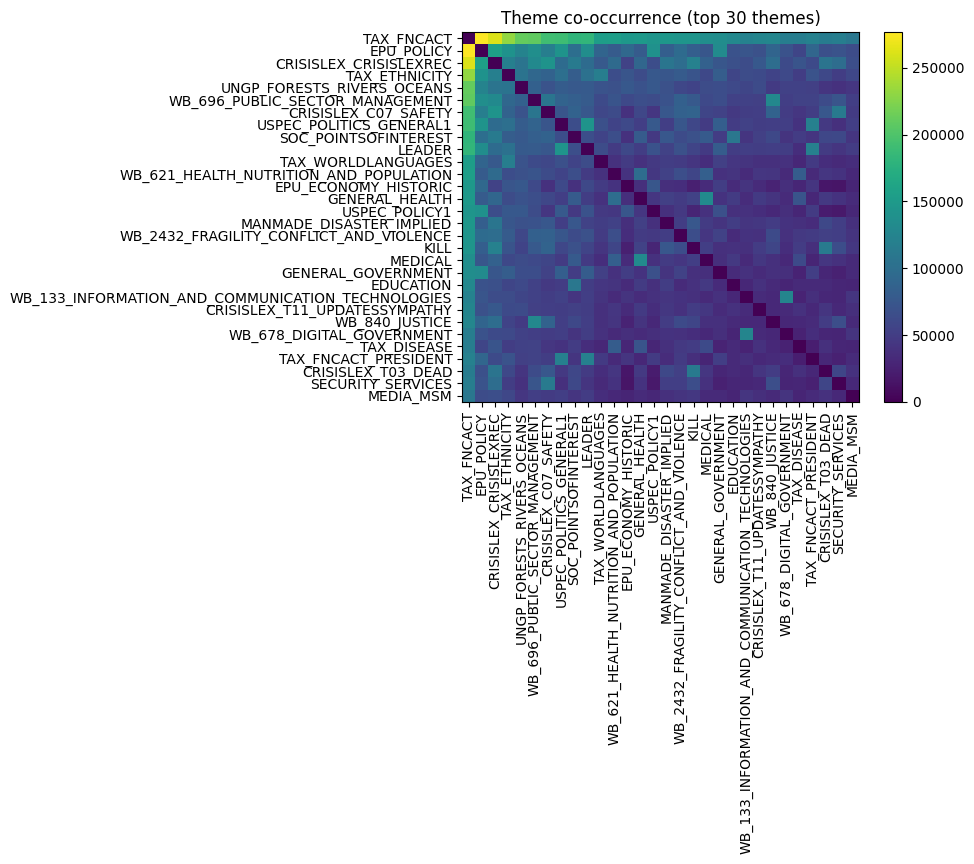

In [16]:
from collections import Counter
import itertools

if theme_col:
    topN = 30
    long = explode_list_col(gkg[[theme_col]].copy(), theme_col)
    top_themes = long[theme_col].value_counts().head(topN).index.tolist()
    top_set = set(top_themes)

    pair_counts = Counter()
    for s in gkg[theme_col].fillna("").astype(str):
        items = [t.strip() for t in s.split(";") if t.strip() in top_set]
        items = sorted(set(items))
        for a, b in itertools.combinations(items, 2):
            pair_counts[(a,b)] += 1

    idx = {t:i for i,t in enumerate(top_themes)}
    M = np.zeros((topN, topN), dtype=int)
    for (a,b), v in pair_counts.items():
        i, j = idx[a], idx[b]
        M[i,j] = v
        M[j,i] = v

    plt.figure()
    plt.imshow(M, aspect="auto")
    plt.title("Theme co-occurrence (top 30 themes)")
    plt.xticks(range(topN), top_themes, rotation=90)
    plt.yticks(range(topN), top_themes)
    plt.colorbar()
    plt.tight_layout()
    plt.show()


# Analysis of anomalous days in terms of daily volume 

Anomalous days (|z|>=2):
Series([], dtype: float64)


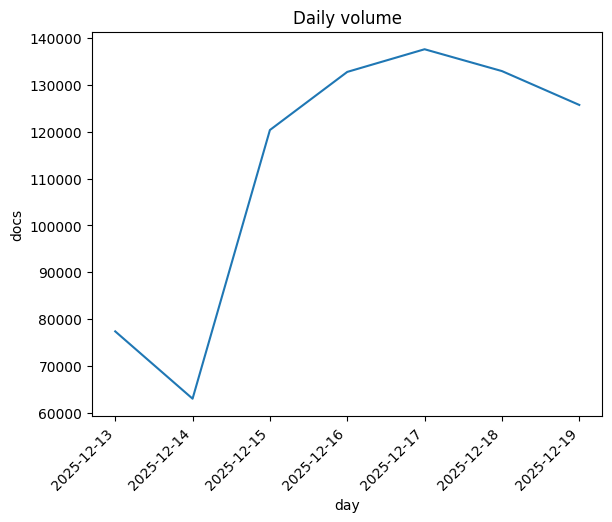

In [17]:
daily_vol = gkg.groupby("day").size().sort_index()
z = (daily_vol - daily_vol.mean()) / (daily_vol.std(ddof=0) + 1e-9)

print("Anomalous days (|z|>=2):")
print(z[abs(z) >= 2].sort_values(ascending=False))

plt.figure()
plt.plot(daily_vol.index, daily_vol.values)
plt.title("Daily volume")
plt.xlabel("day")
plt.ylabel("docs")
plt.tight_layout()
plt.xticks(rotation=45, ha="right")
plt.show()


# since the interval we have chosen is small then there is no significant anomalies detected

In [18]:
if "tone" in gkg.columns:
    daily_tone = gkg.groupby("day")["tone"].mean().sort_index()
    zt = (daily_tone - daily_tone.mean()) / (daily_tone.std(ddof=0) + 1e-9)
    print("Tone shock days (|z|>=2):")
    print(zt[abs(zt) >= 2].sort_values(ascending=False))


Tone shock days (|z|>=2):
Series([], Name: tone, dtype: float64)


# Here we extract the entities from the dataset and create a dataframe with entity mentions and their average tone

In [19]:
ENTITY_COLS = ["Persons", "V2Persons", "Organizations", "V2Organizations", "AllNames"]
entity_col = next((c for c in ENTITY_COLS if c in gkg.columns), None)
if entity_col is None:
    raise KeyError(f"None of {ENTITY_COLS} exist in gkg.columns")

tone_bundle = "V2Tone" if "V2Tone" in gkg.columns else ("Tone" if "Tone" in gkg.columns else None)
if tone_bundle is None and "tone" not in gkg.columns:
    raise KeyError("No V2Tone/Tone or parsed tone column found")

In [21]:
def explode_entities(df, entity_col, sep=";"):
    cols = ["window", "tone", entity_col]
    if "wordcount" in df.columns:
        cols.append("wordcount")

    out = df[cols].copy()
    out[entity_col] = out[entity_col].fillna("").astype(str).str.split(sep)
    out = out.explode(entity_col)
    out["entity"] = out[entity_col].astype(str).str.strip()
    out = out[out["entity"] != ""]
    out["entity"] = out["entity"].str.split(",", n=1).str[0].str.strip()
    out = out.drop(columns=[entity_col])
    return out

gkg["date_dt"] = pd.to_datetime(gkg["DATE"], format="%Y%m%d%H%M%S", errors="coerce")
gkg = gkg.dropna(subset=["date_dt"])
gkg["window"] = gkg["date_dt"].dt.floor("h")
entity_docs = explode_entities(gkg, entity_col)

print(entity_docs.shape)
entity_docs.head()


(2718493, 4)


,window,tone,wordcount,entity
0,2025-12-13,8.011869,303.0,lionel messi
1,2025-12-13,5.213270,190.0,hammond reef
2,2025-12-13,-5.525460,862.0,jeffrey cummings
2,2025-12-13,-5.525460,862.0,doris pryor
2,2025-12-13,-5.525460,862.0,todd m lyons


In [22]:
entity_tone = (entity_docs.groupby("entity")
              .agg(mentions=("tone", "size"),
                   mean_tone=("tone", "mean"))
              .dropna(subset=["mean_tone"])
             )

min_mentions = 1000
entity_tone = entity_tone[entity_tone["mentions"] >= min_mentions]

top_pos = entity_tone.sort_values("mean_tone", ascending=False).head(20)

print(top_pos)

                   mentions  mean_tone
entity                                
alex warren            1185   4.300033
mariah carey           1303   3.620907
snoop dogg             1157   3.311635
ed sheeran             1842   3.013447
santa claus            2853   2.886979
asia pacific           1042   2.845786
reba mcentire          1027   2.759016
taylor swift           3664   2.471849
josh allen             1477   1.907560
travis kelce           2214   1.855737
lady gaga              1117   1.772334
bruce springsteen      1049   1.692911
elijah wood            1021   1.647689
paul mccartney         1230   1.576871
john cusack            1213   1.552290
jesus christ           1104   1.405174
abu dhabi              2038   1.125085
narendra modi          4081   1.107651
elton john             1538   0.955566
jack nicholson         1235   0.913535


# Visualise top 20 entities with most negative and most positive mean tone

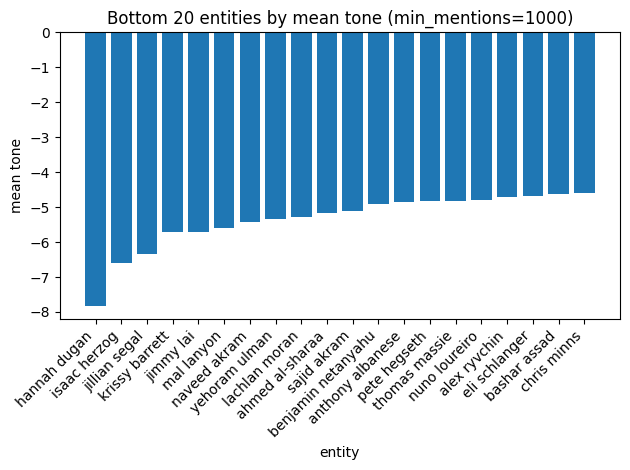

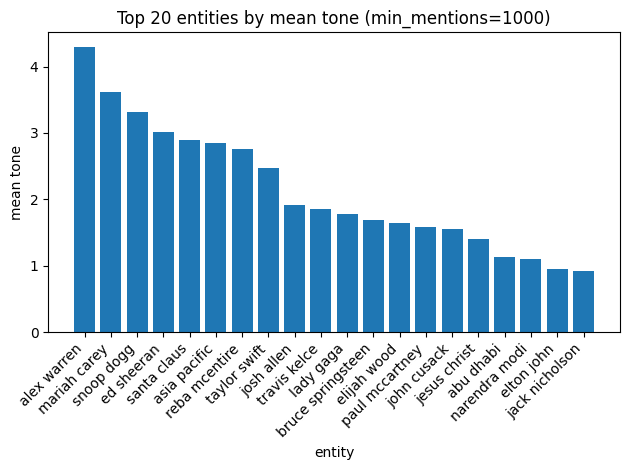

In [23]:
top_neg = entity_tone.sort_values("mean_tone", ascending=True).head(20)

plt.figure()
plt.bar(range(len(top_neg)), top_neg["mean_tone"].to_numpy())
plt.title(f"Bottom 20 entities by mean tone (min_mentions={min_mentions})")
plt.xlabel("entity")
plt.ylabel("mean tone")
plt.xticks(range(len(top_neg)), top_neg.index.astype(str), rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure()
plt.bar(range(len(top_pos)), top_pos["mean_tone"].to_numpy())
plt.title(f"Top 20 entities by mean tone (min_mentions={min_mentions})")
plt.xlabel("entity")
plt.ylabel("mean tone")
plt.xticks(range(len(top_pos)), top_pos.index.astype(str), rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [24]:
stats = (entity_docs.groupby("entity")
         .agg(
             mentions=("entity","size"),
             mean_tone=("tone","mean"),
             median_tone=("tone","median"),
             neg_share=("tone", lambda s: (s < -2).mean()),
             pos_share=("tone", lambda s: (s >  2).mean()),
         )
         .sort_values("mentions", ascending=False))

top20 = stats.head(20)
print(top20)


                  mentions  mean_tone  median_tone  neg_share  pos_share
entity                                                                  
donald trump         51925  -2.406580    -2.320442   0.535426   0.068676
los angeles          27019  -1.304263    -1.149425   0.409305   0.179318
rob reiner           25294  -2.704938    -2.898551   0.606982   0.063968
nick reiner          18015  -3.404459    -4.255319   0.716403   0.033583
carl reiner          13190  -2.248669    -2.805119   0.562547   0.065656
michele reiner       12756  -3.139644    -4.255319   0.697711   0.040138
anthony albanese     11899  -4.840924    -4.647160   0.877889   0.006135
estelle reiner        9191  -3.253882    -4.255319   0.745621   0.002938
joe biden             7832  -2.208072    -1.881331   0.464888   0.044561
keir starmer          6821  -2.717119    -2.917153   0.601525   0.132972
naveed akram          6381  -5.414172    -5.359477   0.933083   0.000784
chris minns           6207  -4.599142    -4.755435 

# we can also see what is the most mentioned entity in the dataset 

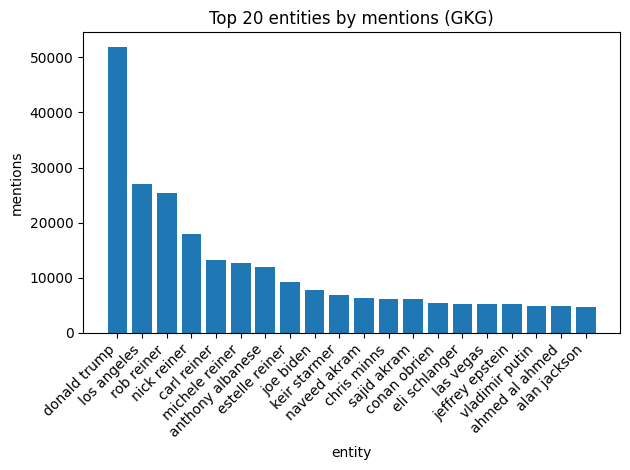

In [25]:
labels = top20.index.astype(str).tolist()
values = top20["mentions"].to_numpy()

plt.figure()
plt.bar(range(len(top20)), values)
plt.title("Top 20 entities by mentions (GKG)")
plt.xlabel("entity")
plt.ylabel("mentions")

plt.xticks(range(len(top20)), labels, rotation=45, ha="right")
plt.tight_layout()
plt.show()


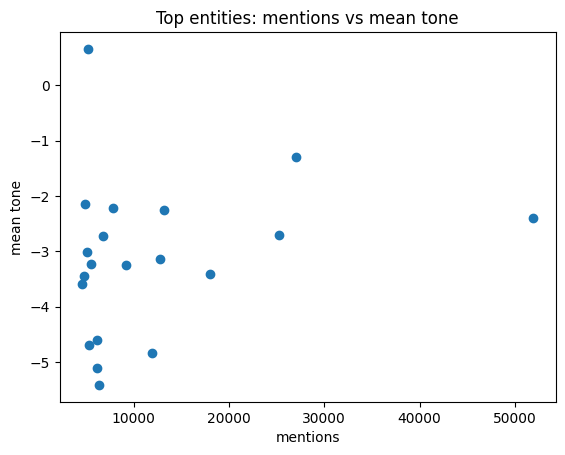

In [26]:
plt.figure()
plt.scatter(top20["mentions"], top20["mean_tone"])
plt.title("Top entities: mentions vs mean tone")
plt.xlabel("mentions")
plt.ylabel("mean tone")
plt.show()


# Tone of the most common entities 

C:\Users\hucu\AppData\Local\Temp\ipykernel_37112\4162577150.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=top10_entities, showfliers=False)


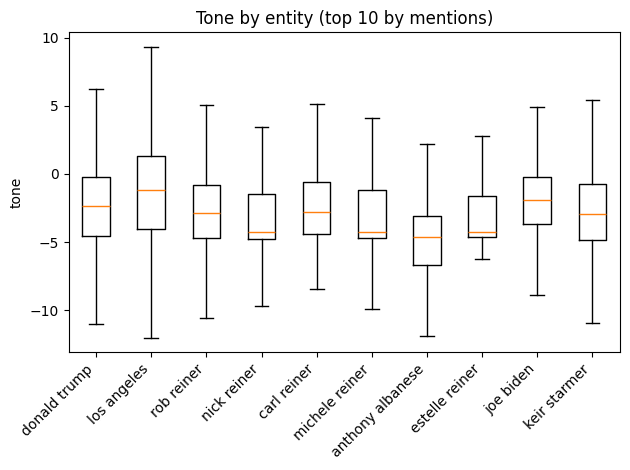

In [27]:
top10_entities = stats.head(10).index.tolist()
data = [entity_docs.loc[entity_docs["entity"]==e, "tone"].dropna().astype(float).values for e in top10_entities]

plt.figure()
plt.boxplot(data, labels=top10_entities, showfliers=False)
plt.title("Tone by entity (top 10 by mentions)")
plt.xticks(rotation=45, ha="right")
plt.ylabel("tone")
plt.tight_layout()
plt.show()


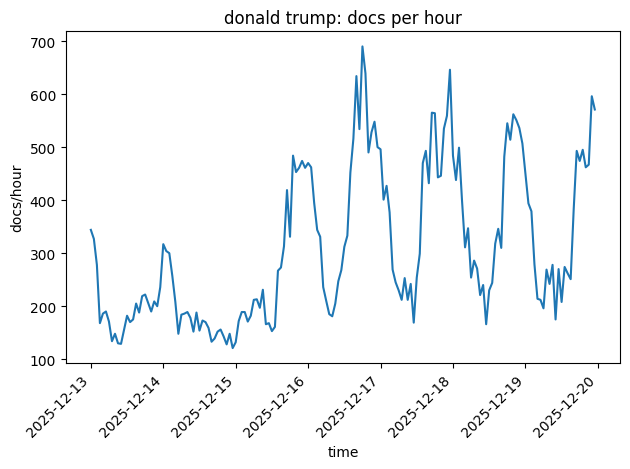

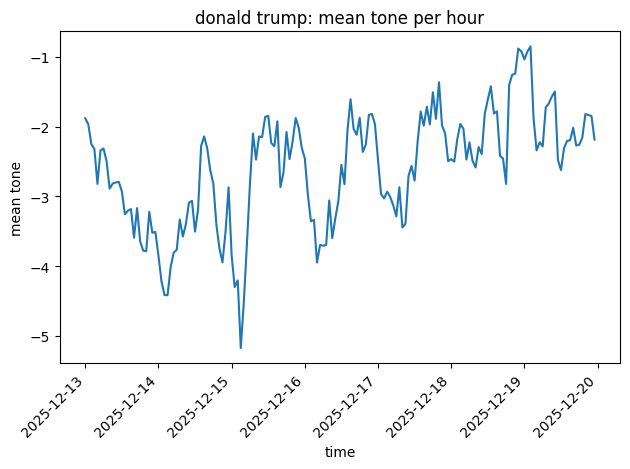

In [28]:
e0 = top10_entities[0]

ts = (entity_docs[entity_docs["entity"]==e0]
      .groupby("window")
      .agg(docs=("tone","size"), mean_tone=("tone","mean"))
      .reset_index()
      .sort_values("window"))

plt.figure()
plt.plot(ts["window"], ts["docs"])
plt.title(f"{e0}: docs per hour")
plt.xlabel("time")
plt.ylabel("docs/hour")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(ts["window"], ts["mean_tone"])
plt.title(f"{e0}: mean tone per hour")
plt.xlabel("time")
plt.ylabel("mean tone")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



In [29]:
top_entities = stats.head(50).index.tolist()
top_entities[:10], len(top_entities)


(['donald trump',
  'los angeles',
  'rob reiner',
  'nick reiner',
  'carl reiner',
  'michele reiner',
  'anthony albanese',
  'estelle reiner',
  'joe biden',
  'keir starmer'],
 50)

# Exctraction of the Wikipedia edits data for the entities found in GDELT dataset

# Find the wikipedia pages for the top entities

In [30]:
import requests
import time

SESSION = requests.Session()
SESSION.headers.update({
    "User-Agent": "GDELT-WikiEdits-Correlation/0.1 (student project; contact: 01171199@pw.edu.pl)"
})

def wiki_search_title(query, wiki="en.wikipedia.org", sleep_s=0.2):
    url = f"https://{wiki}/w/api.php"
    params = {
        "action": "query",
        "format": "json",
        "list": "search",
        "srsearch": query,
        "srlimit": 1
    }
    r = SESSION.get(url, params=params, timeout=30)
    if r.status_code == 429:
        time.sleep(2)
        r = SESSION.get(url, params=params, timeout=30)

    r.raise_for_status()
    hits = r.json().get("query", {}).get("search", [])
    time.sleep(sleep_s)
    return hits[0]["title"] if hits else None


entity_to_title = {}
for e in top_entities:
    title = wiki_search_title(e)
    if title:
        entity_to_title[e] = title

list(entity_to_title.items())[:10], len(entity_to_title)


([('donald trump', 'Donald Trump'),
  ('los angeles', 'Los Angeles'),
  ('rob reiner', 'Rob Reiner'),
  ('nick reiner', 'Rob Reiner'),
  ('carl reiner', 'Carl Reiner'),
  ('michele reiner', 'Rob Reiner'),
  ('anthony albanese', 'Anthony Albanese'),
  ('estelle reiner', 'Estelle Reiner'),
  ('joe biden', 'Joe Biden'),
  ('keir starmer', 'Keir Starmer')],
 50)

# Since we have extracted the wikipedia titles, we can also fetch edits for these pages

In [ ]:
import time
import requests
import pandas as pd

SESSION = requests.Session()
SESSION.headers.update({
    "User-Agent": "GDELT-WikiEdits-Correlation/0.1 (student project; contact: 01171199@pw.edu.pl)",
    "Accept": "application/json"
})

def fetch_page_revisions(title, start_iso, end_iso, wiki="en.wikipedia.org", sleep_s=0.15, max_pages=200):
    """
    Fetch revisions for a page between [start_iso, end_iso] inclusive-ish.
    start_iso/end_iso like '2025-12-11T00:00:00Z'
    Returns DataFrame(title, timestamp, user)
    """
    url = f"https://{wiki}/w/api.php"
    params = {
        "action": "query",
        "format": "json",
        "prop": "revisions",
        "titles": title,
        "rvprop": "timestamp|user",
        "rvstart": start_iso,
        "rvend": end_iso,
        "rvdir": "newer",
        "rvlimit": "max",
        "redirects": 1
    }

    rows = []
    for _ in range(max_pages):
        for attempt in range(5):
            r = SESSION.get(url, params=params, timeout=60)
            if r.status_code in (429, 503):
                time.sleep(2 * (attempt + 1))
                continue
            r.raise_for_status()
            break

        js = r.json()
        pages = js.get("query", {}).get("pages", {})
        if not pages:
            break

        page = next(iter(pages.values()))
        if "missing" in page:
            break

        revs = page.get("revisions", [])
        for rv in revs:
            rows.append({
                "title": title,
                "timestamp": rv.get("timestamp"),
                "user": rv.get("user")
            })

        cont = js.get("continue")
        if not cont:
            break
        params.update(cont)

        time.sleep(sleep_s)

    return pd.DataFrame(rows)


start_iso = "2025-12-13T00:00:00Z"
end_iso   = "2025-12-19T23:59:59Z"

wiki_rows = []
for e, title in entity_to_title.items():
    df_r = fetch_page_revisions(title, start_iso, end_iso)
    if not df_r.empty:
        df_r["entity"] = e
        wiki_rows.append(df_r)

wiki_edits = pd.concat(wiki_rows, ignore_index=True) if wiki_rows else pd.DataFrame()
print(wiki_edits.shape)
wiki_edits.head(50)



(4360, 4)


,title,timestamp,user,entity
0,Donald Trump,2025-12-13T13:27:47Z,Maxeto0910,donald trump
1,Donald Trump,2025-12-13T18:48:01Z,Maxeto0910,donald trump
2,Donald Trump,2025-12-15T05:26:11Z,Bsherr,donald trump
3,Donald Trump,2025-12-15T05:28:26Z,Bsherr,donald trump
4,Donald Trump,2025-12-15T05:31:24Z,Bsherr,donald trump


In [32]:
wiki_edits["timestamp"] = pd.to_datetime(wiki_edits["timestamp"], errors="coerce").dt.tz_convert(None)
wiki_edits = wiki_edits.dropna(subset=["timestamp"])
wiki_edits["window"] = wiki_edits["timestamp"].dt.floor("h")

y = (wiki_edits.groupby(["entity", "title", "window"])
     .agg(edits=("window","size"), editors=("user", pd.Series.nunique))
     .reset_index())
y.head()


,entity,title,window,edits,editors
0,ahmed al ahmed,Ahmed Al-Ahmed,2025-12-14 13:00:00,4,1
1,ahmed al ahmed,Ahmed Al-Ahmed,2025-12-14 14:00:00,1,1
2,ahmed al ahmed,Ahmed Al-Ahmed,2025-12-14 15:00:00,5,4
3,ahmed al ahmed,Ahmed Al-Ahmed,2025-12-14 17:00:00,1,1
4,ahmed al ahmed,Ahmed Al-Ahmed,2025-12-14 18:00:00,2,2


In [33]:
def mentions_entity(cell, entity, sep=";"):
    if not isinstance(cell, str) or not cell:
        return False
    items = [x.strip() for x in cell.split(sep) if x.strip()]
    return any(x.split(",")[0].strip() == entity for x in items)

gkg = gkg.copy()
gkg["date_dt"] = pd.to_datetime(gkg["DATE"], format="%Y%m%d%H%M%S", errors="coerce")
gkg = gkg.dropna(subset=["date_dt"])
gkg["window"] = gkg["date_dt"].dt.floor("h")

entity_docs = explode_entities(gkg, entity_col)



In [34]:
top_entities = stats.head(50).index.tolist()
entity_docs_50 = entity_docs[entity_docs["entity"].isin(top_entities)].copy()


# Create an aggregated view of wikipedia edits for the entities found in GDELT dataset

In [36]:
entities = list(entity_to_title.keys())

entity_docs_sub = entity_docs[entity_docs["entity"].isin(entities)].copy()

agg = {
    "gkg_docs": ("tone", "size"),
    "mean_tone": ("tone", "mean"),
    "std_tone": ("tone", "std"),
    "neg_share": ("tone", lambda s: (s < -2).mean()),
    "pos_share": ("tone", lambda s: (s >  2).mean()),
}
if "wordcount" in entity_docs_sub.columns:
    agg["mean_wordcount"] = ("wordcount", "mean")

X = (entity_docs_sub.groupby(["entity", "window"])
     .agg(**agg)
     .reset_index())

print(X.shape)
X.head()


(7076, 8)


,entity,window,gkg_docs,mean_tone,std_tone,neg_share,pos_share,mean_wordcount
0,ahmed al ahmed,2025-12-14 13:00:00,2,-5.583636,0.325718,1.000000,0.0,264.500000
1,ahmed al ahmed,2025-12-14 14:00:00,8,-6.890074,5.605092,1.000000,0.0,735.000000
2,ahmed al ahmed,2025-12-14 15:00:00,5,-5.096119,3.147458,0.800000,0.0,732.200000
3,ahmed al ahmed,2025-12-14 16:00:00,8,-6.198158,2.100349,0.875000,0.0,558.750000
4,ahmed al ahmed,2025-12-14 17:00:00,28,-2.985981,1.030457,0.928571,0.0,981.607143


In [37]:
import pandas as pd

y = y.copy()
X = X.copy()

y["window"] = pd.to_datetime(y["window"], errors="coerce")
X["window"] = pd.to_datetime(X["window"], errors="coerce")

if getattr(y["window"].dtype, "tz", None) is not None:
    y["window"] = y["window"].dt.tz_convert(None)
if getattr(X["window"].dtype, "tz", None) is not None:
    X["window"] = X["window"].dt.tz_convert(None)

y = y.groupby(["entity", "window"], as_index=False).agg(edits=("edits","sum"), editors=("editors","sum") if "editors" in y.columns else ("edits","size"))
X = X.groupby(["entity", "window"], as_index=False).mean(numeric_only=True)

data = (y.merge(X, on=["entity","window"], how="inner")
          .sort_values(["entity","window"])
          .reset_index(drop=True))

data["edits_tplus1"] = data.groupby("entity")["edits"].shift(-1)

data = data.dropna(subset=["edits_tplus1"])

data.head()


,entity,window,edits,editors,gkg_docs,mean_tone,std_tone,neg_share,pos_share,mean_wordcount,edits_tplus1
0,ahmed al ahmed,2025-12-14 13:00:00,4,1,2.0,-5.583636,0.325718,1.000000,0.0,264.500000,1.0
1,ahmed al ahmed,2025-12-14 14:00:00,1,1,8.0,-6.890074,5.605092,1.000000,0.0,735.000000,5.0
2,ahmed al ahmed,2025-12-14 15:00:00,5,4,5.0,-5.096119,3.147458,0.800000,0.0,732.200000,1.0
3,ahmed al ahmed,2025-12-14 17:00:00,1,1,28.0,-2.985981,1.030457,0.928571,0.0,981.607143,2.0
4,ahmed al ahmed,2025-12-14 18:00:00,2,2,50.0,-3.489148,1.535753,0.920000,0.0,943.300000,2.0


In [38]:
data["hour"] = data["window"].dt.hour
data["dow"]  = data["window"].dt.dayofweek

for k in [1,2,3,6,12,24]:
    data[f"edits_lag{k}"] = data.groupby("entity")["edits"].shift(k)

for k in [1,2,3,6]:
    data[f"gkg_docs_lag{k}"] = data.groupby("entity")["gkg_docs"].shift(k)
    data[f"mean_tone_lag{k}"] = data.groupby("entity")["mean_tone"].shift(k)

data = data.dropna()


In [68]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

cut = data["window"].quantile(0.8)
train = data[data["window"] <= cut].copy()
test  = data[data["window"] >  cut].copy()

target = "edits_tplus1"
feature_cols = [
    "hour","dow",
    "edits_lag1","edits_lag2","edits_lag3","edits_lag6","edits_lag12","edits_lag24",
    "gkg_docs","mean_tone","neg_share","pos_share",
    "gkg_docs_lag1","gkg_docs_lag2","mean_tone_lag1","mean_tone_lag2"
]

for c in feature_cols + [target]:
    train[c] = pd.to_numeric(train[c], errors="coerce")
    test[c] = pd.to_numeric(test[c], errors="coerce")

train = train.dropna(subset=feature_cols + [target])
test  = test.dropna(subset=feature_cols + [target])

X_train, y_train = train[feature_cols], train[target]
X_test,  y_test  = test[feature_cols],  test[target]

models = {}

models["Ridge"] = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("model", Ridge(alpha=1))
])

models["RandomForest"] = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=2
)

models["GradientBoosting"] = GradientBoostingRegressor(
    random_state=42
)


results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    pred = np.clip(pred, 0, None)

    mae = mean_absolute_error(y_test, pred)
    rmse = mean_squared_error(y_test, pred)

    results.append((name, mae, rmse))
    print(f"{name:16s}  MAE={mae:.3f}  RMSE={rmse:.3f}")

results_df = pd.DataFrame(results, columns=["model", "MAE", "RMSE"]).sort_values("MAE")
results_df


Ridge             MAE=1.846  RMSE=6.439
RandomForest      MAE=4.392  RMSE=27.818
GradientBoosting  MAE=3.974  RMSE=22.011


,model,MAE,RMSE
0,Ridge,1.845719,6.438671
2,GradientBoosting,3.973821,22.011175
1,RandomForest,4.391535,27.818180
